In [71]:
!pip install scanpy anndata pyscenic pympler

In [72]:
import scanpy as sc
import os
import anndata
import pandas as pd

path = "/kaggle/input/dominguez-immune-two-donors"
files = sorted([f for f in os.listdir(path) if f.endswith(".h5ad")])
all_adatas = []
i = 0
for f in files:
    print(i)
    i += 1
    ad = sc.read_h5ad(os.path.join(path, f))
    # Annotate with dataset or batch info
    ad.obs["batch"] = f.split("_")[0]  # adapt to your filename format
    all_adatas.append(ad)

# Concatenate into one big AnnData object
adata = anndata.concat(all_adatas, join="outer", label="batch", fill_value=0)

del all_adatas
del ad

import gc
gc.collect()


0


184

In [73]:
print(adata.var.head(5))

Empty DataFrame
Columns: []
Index: [RP11-34P13, RP11-34P13-3, AP006222, LINC01409, FAM87B]


In [74]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=30000, flavor="seurat")
adata = adata[:, adata.var.highly_variable]

In [75]:
print(adata.shape)

(29773, 23944)


In [76]:
print(adata.var.columns)

Index(['highly_variable', 'means', 'dispersions', 'dispersions_norm'], dtype='object')


In [77]:
# from pyscenic.aucell import GeneSignature

# GMT_FNAME = "/content/h.all.v2025.1.Hs.symbols.gmt"

# # Try this first - use default gene_separator
# signatures = GeneSignature.from_gmt(GMT_FNAME, field_separator="\t")

# # If that doesn't work, try explicitly setting gene_separator to None
# # signatures = GeneSignature.from_gmt(GMT_FNAME, field_separator="\t", gene_separator=None)

# # Check if it worked
# print(f"Loaded {len(signatures)} gene signatures")
# print(f"First signature: {signatures[49].name}")
# print(f"Number of genes in first signature: {len(signatures[0].genes)}")
# print(f"First few genes: {list(signatures[0].genes)[:5]}")

In [78]:
from pyscenic.aucell import GeneSignature
import pandas as pd
import numpy as np

# Create expression matrix
ex_matrix = pd.DataFrame(adata.X.toarray(), index=adata.obs_names, columns=adata.var_names)

# Load gene signatures
GMT_FNAME = "/kaggle/input/pathways-50/h.all.v2025.1.Hs.symbols.gmt"
signatures = GeneSignature.from_gmt(GMT_FNAME, field_separator="\t")

# Create rankings
from pyscenic.aucell import create_rankings, enrichment
rnk_mtx = create_rankings(ex_matrix)

# Calculate AUCs
aucs = []
signature_names = []
print("Now calculating AUCs")
for signature in signatures:
    auc_scores = enrichment(rnk_mtx, signature)
    aucs.append(auc_scores)
    signature_names.append(signature.name)

Now calculating AUCs


In [79]:
# Convert to DataFrame
aucs_df = pd.DataFrame(np.column_stack(aucs), 
                      index=ex_matrix.index, 
                      columns=signature_names)
print(aucs_df)

                               HALLMARK_ADIPOGENESIS  \
Pan_T7935490_AAACCTGCAAATTGCC               0.067085   
Pan_T7935490_AAACGGGCATCTGGTA               0.065807   
Pan_T7935490_AAACGGGTCTTGCATT               0.058275   
Pan_T7935490_AAAGCAATCATCGCTC               0.047342   
Pan_T7935490_AAAGTAGCAGTCACTA               0.074237   
...                                              ...   
Pan_T7935489_TTCTCCTCATCCAACA               0.073828   
Pan_T7935489_TTGAACGAGTTGTCGT               0.059856   
Pan_T7935489_TTGAACGCACGCCAGT               0.045782   
Pan_T7935489_TTGTAGGAGGGCATGT               0.063347   
Pan_T7935489_TTTACTGGTTGTGGCC               0.048663   

                               HALLMARK_ALLOGRAFT_REJECTION  \
Pan_T7935490_AAACCTGCAAATTGCC                      0.140777   
Pan_T7935490_AAACGGGCATCTGGTA                      0.165533   
Pan_T7935490_AAACGGGTCTTGCATT                      0.143181   
Pan_T7935490_AAAGCAATCATCGCTC                      0.154553   
Pan_T7935490

In [80]:

# Filter pathways that appear in top 5% of >0.5% of cells
top5_percentile_mask = aucs_df.apply(lambda row: row >= np.percentile(row, 95), axis=1)
pathway_frequencies = top5_percentile_mask.sum(axis=0) / top5_percentile_mask.shape[0]
selected_pathways = pathway_frequencies[pathway_frequencies > 0.005].index

# Final filtered AUCell matrix
filtered_aucs = aucs_df[selected_pathways]

# Store in AnnData object
adata.obsm["AUCell_scores_filtered"] = filtered_aucs.loc[adata.obs_names]

/tmp/ipykernel_36/129367736.py:10: ImplicitModificationWarning: Setting element `.obsm['AUCell_scores_filtered']` of view, initializing view as actual.
  adata.obsm["AUCell_scores_filtered"] = filtered_aucs.loc[adata.obs_names]


In [81]:
print(len(selected_pathways))

20


In [82]:
print(adata.obsm["AUCell_scores_filtered"])

                               HALLMARK_ALLOGRAFT_REJECTION  \
Pan_T7935490_AAACCTGCAAATTGCC                      0.140777   
Pan_T7935490_AAACGGGCATCTGGTA                      0.165533   
Pan_T7935490_AAACGGGTCTTGCATT                      0.143181   
Pan_T7935490_AAAGCAATCATCGCTC                      0.154553   
Pan_T7935490_AAAGTAGCAGTCACTA                      0.115625   
...                                                     ...   
Pan_T7935489_TTCTCCTCATCCAACA                      0.149609   
Pan_T7935489_TTGAACGAGTTGTCGT                      0.113004   
Pan_T7935489_TTGAACGCACGCCAGT                      0.104573   
Pan_T7935489_TTGTAGGAGGGCATGT                      0.145155   
Pan_T7935489_TTTACTGGTTGTGGCC                      0.145683   

                               HALLMARK_ANGIOGENESIS  HALLMARK_APOPTOSIS  \
Pan_T7935490_AAACCTGCAAATTGCC               0.025230            0.114222   
Pan_T7935490_AAACGGGCATCTGGTA               0.026590            0.097077   
Pan_T7935490_AA

In [83]:
# --- Add "pathway1" (most active) to adata.obs ---
# Find the pathway with the maximum score for each cell
adata.obs["pathway1"] = aucs_df.idxmax(axis=1)

# --- Add "pathway2" (second most active) to adata.obs ---
# Define a function to get the second largest pathway name (index) for a given row (cell)
def get_second_largest_pathway_name(row):
    # Sort the row values in descending order and get the index (pathway names)
    sorted_pathways = row.sort_values(ascending=False).index

    # If there are at least two pathways, return the second one
    if len(sorted_pathways) >= 2:
        return sorted_pathways[1]
    else:
        # Return a placeholder for cells that don't have a second pathway
        # (e.g., if a cell only has one non-zero pathway score, or fewer than 2 pathways overall)
        return np.nan

# Apply this function across each row (cell) to get the second most active pathway
adata.obs["pathway2"] = aucs_df.apply(get_second_largest_pathway_name, axis=1)

# --- Optional: Fill NaN values if some cells didn't have a second pathway ---
# If you prefer 'N/A' or another string instead of NaN for better readability
adata.obs["pathway2"] = adata.obs["pathway2"].fillna("No_Second_Pathway")


print("\n--- Updated adata.obs (first 5 rows and new columns) ---")
print(adata.obs.head())


--- Updated adata.obs (first 5 rows and new columns) ---
                                                            cell_type tissue  \
Pan_T7935490_AAACCTGCAAATTGCC              CD4-positive helper T cell  ileum   
Pan_T7935490_AAACGGGCATCTGGTA  CD8-positive, alpha-beta memory T cell  ileum   
Pan_T7935490_AAACGGGTCTTGCATT  CD8-positive, alpha-beta memory T cell  ileum   
Pan_T7935490_AAAGCAATCATCGCTC  CD8-positive, alpha-beta memory T cell  ileum   
Pan_T7935490_AAAGTAGCAGTCACTA                      gamma-delta T cell  ileum   

                              batch_condition      organism      assay  \
Pan_T7935490_AAACCTGCAAATTGCC             A29  Homo sapiens  10x 5' v1   
Pan_T7935490_AAACGGGCATCTGGTA             A29  Homo sapiens  10x 5' v1   
Pan_T7935490_AAACGGGTCTTGCATT             A29  Homo sapiens  10x 5' v1   
Pan_T7935490_AAAGCAATCATCGCTC             A29  Homo sapiens  10x 5' v1   
Pan_T7935490_AAAGTAGCAGTCACTA             A29  Homo sapiens  10x 5' v1   

                

In [84]:
output_filename = "adata_with_pathway_info.h5ad"
adata.write(output_filename)

... storing 'pathway1' as categorical
... storing 'pathway2' as categorical



The second most popular pathway (as the most active for cells) is: 'HALLMARK_TNFA_SIGNALING_VIA_NFKB' with 3124 cells.


/tmp/ipykernel_36/2374574550.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=most_active_pathways, order=pathway_counts.index, palette='viridis')


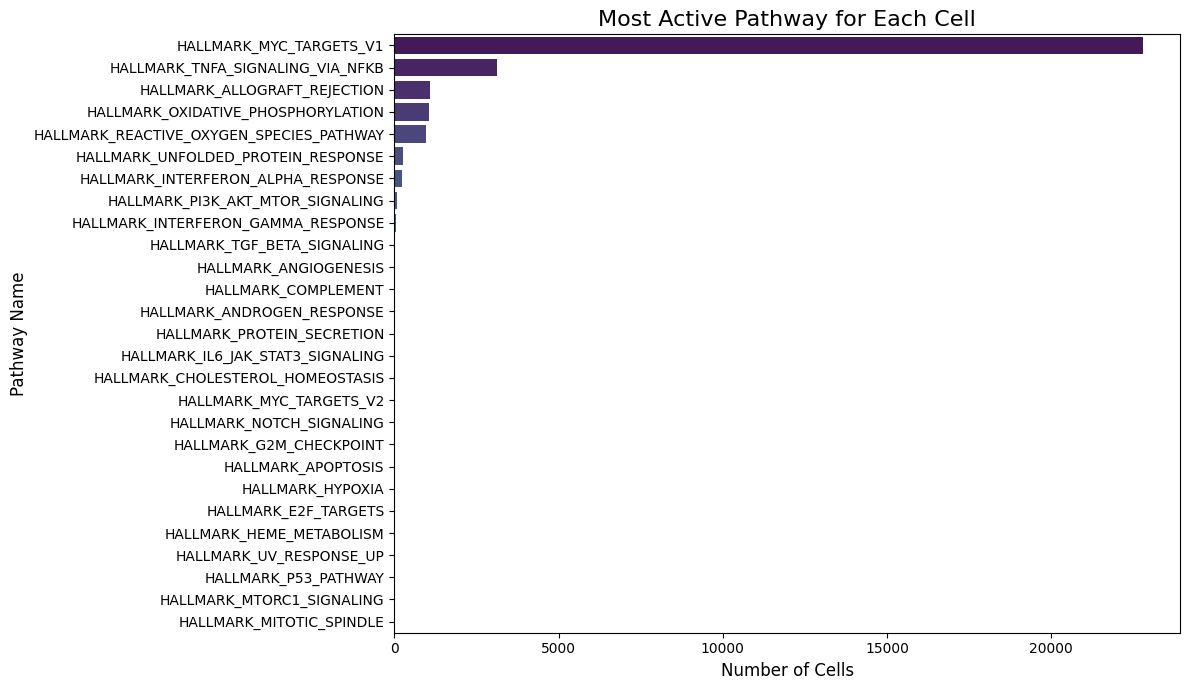


Analysis complete. The histogram above shows how many cells have each pathway as their highest-scoring pathway.

The second most popular pathway (as the second most active for cells) is: 'HALLMARK_ALLOGRAFT_REJECTION' with 6675 cells.


/tmp/ipykernel_36/2374574550.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=second_most_active_pathways, order=pathway_counts.index, palette='viridis')


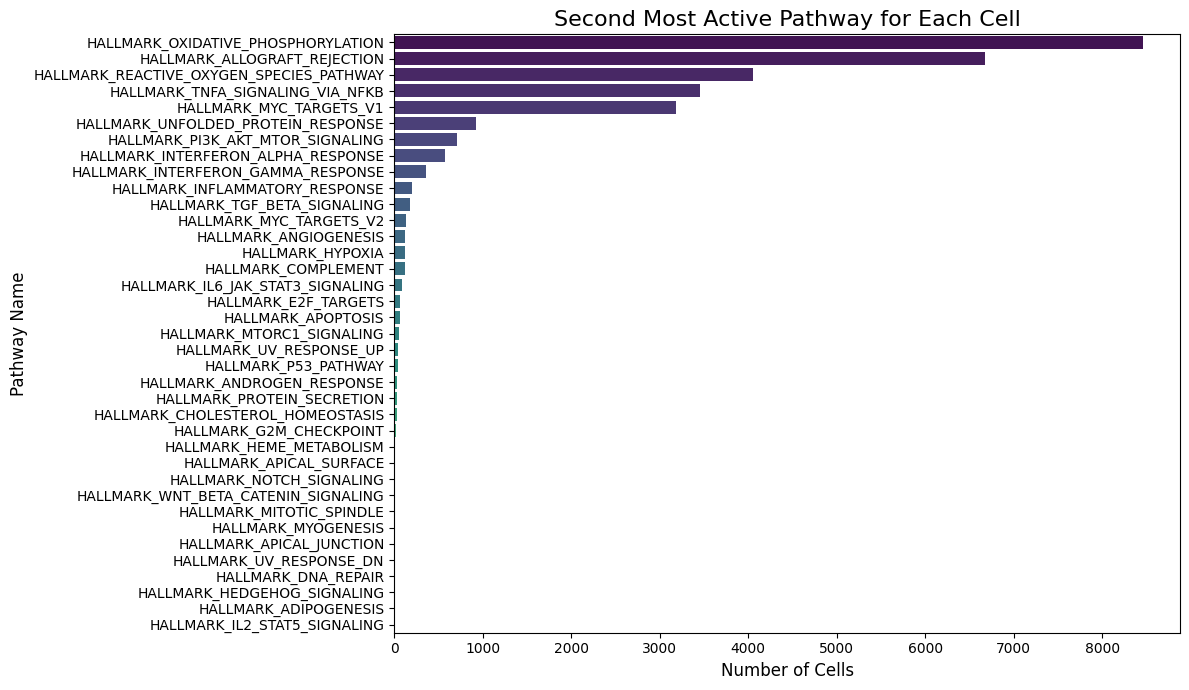


Analysis complete. The histogram above shows how many cells have each pathway as their second highest-scoring pathway.


In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def get_second_largest_pathway(row):
    if len(row) < 2: # Check if there are at least two pathways
        return np.nan # Or a placeholder for cells with fewer than 2 pathways
    return row.nlargest(2).index[-1]


# Use idxmax() along axis 1 (columns) to get the column name (pathway)
# that has the maximum value for each row (cell).
most_active_pathways = aucs_df.idxmax(axis=1)

# --- Determine and print the second most popular pathway ---
# Get the counts of each pathway being the most active, sorted in descending order
pathway_counts = most_active_pathways.value_counts()

if len(pathway_counts) >= 2:
    second_most_popular_pathway = pathway_counts.index[1]
    second_most_popular_count = pathway_counts.iloc[1]
    print(f"\nThe second most popular pathway (as the most active for cells) is: '{second_most_popular_pathway}' with {second_most_popular_count} cells.")
elif len(pathway_counts) == 1:
    print("\nThere is only one pathway that is the most active across all cells, so no second most popular pathway.")
else:
    print("\nNo pathways found as most active for any cell.")


# --- Visualize the results in a histogram (bar plot) ---
plt.figure(figsize=(12, 7)) # Adjust figure size for better readability

# Create a count plot (histogram for categorical data)
sns.countplot(y=most_active_pathways, order=pathway_counts.index, palette='viridis')

plt.title('Most Active Pathway for Each Cell', fontsize=16)
plt.xlabel('Number of Cells', fontsize=12)
plt.ylabel('Pathway Name', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

print("\nAnalysis complete. The histogram above shows how many cells have each pathway as their highest-scoring pathway.")

second_most_active_pathways = aucs_df.apply(get_second_largest_pathway, axis=1)

# Remove any NaN entries if some cells didn't have a second pathway
second_most_active_pathways = second_most_active_pathways.dropna()

# --- Determine and print the second most popular pathway overall (from the 'second most active' list) ---
# Get the counts of each pathway being the second most active, sorted in descending order
pathway_counts = second_most_active_pathways.value_counts()

if len(pathway_counts) >= 2:
    # The "second most popular" here means the pathway that appeared as the
    # second highest score most frequently across all cells.
    second_most_popular_from_second_active = pathway_counts.index[1]
    second_most_popular_count_from_second_active = pathway_counts.iloc[1]
    print(f"\nThe second most popular pathway (as the second most active for cells) is: '{second_most_popular_from_second_active}' with {second_most_popular_count_from_second_active} cells.")
elif len(pathway_counts) == 1:
    print("\nOnly one pathway was identified as the second most active across cells, so no second most popular pathway from this list.")
else:
    print("\nNo second most active pathways found for any cell, or all were dropped due to insufficient data.")


# --- Visualize the results in a histogram (bar plot) ---
plt.figure(figsize=(12, 7)) # Adjust figure size for better readability

# Create a count plot (histogram for categorical data)
sns.countplot(y=second_most_active_pathways, order=pathway_counts.index, palette='viridis')

plt.title('Second Most Active Pathway for Each Cell', fontsize=16)
plt.xlabel('Number of Cells', fontsize=12)
plt.ylabel('Pathway Name', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

print("\nAnalysis complete. The histogram above shows how many cells have each pathway as their second highest-scoring pathway.")


In [86]:
import requests
from bs4 import BeautifulSoup
import time # Import time for rate limiting
import os # Import os for file path handling

def get_webpage_content(url):
    """
    Fetches the HTML content of a given URL and extracts the brief description.

    Args:
        url (str): The URL of the webpage to fetch.

    Returns:
        str: The extracted brief description, or an error message if the request or parsing fails.
    """
    try:
        # Send a GET request to the URL
        response = requests.get(url, timeout=10) # Added timeout
        # Added a small delay to be polite to the server and avoid being blocked
        time.sleep(0.1)

        # Raise an HTTPError for bad responses (4xx or 5xx)
        response.raise_for_status()

        # Parse the HTML content using BeautifulSoup
        soup = BeautifulSoup(response.text, 'html.parser')

        # Find the <th> tag with the text "Brief description"
        # Then find the next sibling <td> tag to get its text
        brief_description_th = soup.find('th', string='Brief description')
        if brief_description_th:
            brief_description_td = brief_description_th.find_next_sibling('td')
            if brief_description_td:
                return brief_description_td.get_text(strip=True)
            else:
                return "Error: Could not find the <td> tag after 'Brief description'."
        else:
            return "Error: Could not find 'Brief description' header on the page."

    except requests.exceptions.Timeout:
        return f"Error: Request timed out for {url}"
    except requests.exceptions.RequestException as e:
        # Handle any request-related errors (e.g., network issues, invalid URL)
        return f"Error fetching {url}: {e}"
    except Exception as e:
        # Handle any other unexpected errors during parsing
        return f"Error parsing content from {url}: {e}"

def process_gmt_content(gmt_data):
    """
    Reads GMT-like content, extracts URLs, and fetches brief descriptions for each.

    Args:
        gmt_data (str): A string containing the content of a .gmt file.
                        Each line should have gene set name, URL, and then genes,
                        separated by tabs or multiple spaces.
    """
    results = []
    lines = gmt_data.strip().split('\n')
    for line in lines:
        parts = line.strip().split('\t') # Split by tab
        if len(parts) >= 2: # Ensure at least name and URL are present
            gene_set_name = parts[0].strip()
            url = parts[1].strip()
            print(f"Fetching description for: {gene_set_name} (URL: {url})")
            description = get_webpage_content(url)
            results.append(f"{gene_set_name}: {description}")
        else:
            results.append(f"Skipping malformed line: {line}")
    return "\n".join(results)


if __name__ == "__main__":
    # Specify the name of your .gmt file
    gmt_filename = "/kaggle/input/pathways-50/h.all.v2025.1.Hs.symbols.gmt" # You can change this to your file's name

    if os.path.exists(gmt_filename):
        try:
            with open(gmt_filename, 'r') as f:
                gmt_file_content = f.read()

            print(f"Starting to process GMT content from {gmt_filename}...")
            processed_results = process_gmt_content(gmt_file_content)
            print("\n--- Processing Complete ---")
            print(processed_results)

        except Exception as e:
            print(f"Error reading or processing the file '{gmt_filename}': {e}")
    else:
        print(f"Error: The file '{gmt_filename}' was not found.")
        print("Please make sure the .gmt file is in the same directory as this script, or provide the full path.")
        # Fallback to the example content if file not found, for demonstration purposes
        print("\n--- Processing example content instead ---")
        gmt_file_content_example = """
ABBUD_LIF_SIGNALING_1_DN	https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/ABBUD_LIF_SIGNALING_1_DN	AHNAK	ALCAM	ANKRD40	ARID1A	BCKDHB	C16orf89	CAPN9	CD24	CYFIP1	DCAF11	DDC	EFNA2	ENPP2	FOXA2	GRIA2	HK2	HOXC9	ITGA6	KLRB1	LIMS1	MTSS2	OSTF1	PELI1	REXO2	STEEP1	SUCLA2	SYTL4	TSPAN7
ABBUD_LIF_SIGNALING_1_UP	https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/ABBUD_LIF_SIGNALING_1_UP	ACAA2	ALDOC	ANXA8L1	BCL3	CEBPB	CXCL14	CYB561	ELF3	FBP1	FGG	GPCPD1	GPX3	GRAMD2B	HAS1	IL1R1	IRF1	KLF10	KNG1	LBP	LCN2	LRG1	MAN1A1	MPO	NMI	PSMB8	PTPN1	RASA3	RGS4	RHOU	RNASE2	SCT	SOCS3	SQOR	ST3GAL1	STAT3	TAPBP	TMEM176A	TMEM176B	TNFRSF1A	TSPAN4	UPP1	VWF	XBP1
ABBUD_LIF_SIGNALING_2_DN	https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/ABBUD_LIF_SIGNALING_2_DN	CGA	CITED2	NALCN	PITX2	PTHLH	SCN1A	ZNF280D
ABBUD_LIF_SIGNALING_2_UP	https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/ABBUD_LIF_SIGNALING_2_UP	ATP1B1	COL11A1	DAB2	DCN	DIO2	EZR	FGFR1	GPX2	JUNB	NRP1	PFKP	PPP2R2B	PTPRO
ABDELMOHSEN_ELAVL4_TARGETS	https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/ABDELMOHSEN_ELAVL4_TARGETS	BCL2	CAB39	CASP3	CDC42	CDH2	DLG4	EIF2AK2	ITGA1	ITGB1	KCNQ2	KMT5A	LEPROTL1	NCAM1	PARP1	RAB10	RHOA
ABDULRAHMAN_KIDNEY_CANCER_VHL_DN	https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/ABDULRAHMAN_KIDNEY_CANCER_VHL_DN	ACTA2	ALDH1A1	ALDH3B1	ITGB3BP	MPPE1	MTMR3	PALLD	PJA2	RHOBTB1	SEC31A	SNRPN	STX11	UGT2B7
        """
        processed_results = process_gmt_content(gmt_file_content_example)
        print(processed_results)


Starting to process GMT content from /kaggle/input/pathways-50/h.all.v2025.1.Hs.symbols.gmt...
Fetching description for: HALLMARK_ADIPOGENESIS (URL: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_ADIPOGENESIS)
Fetching description for: HALLMARK_ALLOGRAFT_REJECTION (URL: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_ALLOGRAFT_REJECTION)
Fetching description for: HALLMARK_ANDROGEN_RESPONSE (URL: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_ANDROGEN_RESPONSE)
Fetching description for: HALLMARK_ANGIOGENESIS (URL: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_ANGIOGENESIS)
Fetching description for: HALLMARK_APICAL_JUNCTION (URL: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_APICAL_JUNCTION)
Fetching description for: HALLMARK_APICAL_SURFACE (URL: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_APICAL_SURFACE)
Fetching description for: HALLMARK_APOPTOSIS (URL: https://www.gsea-msigdb.org/gsea/m

In [87]:
import sys
import gc

del ex_matrix 
del rnk_mtx 
del aucs_df 
del filtered_aucs

gc.collect()
# Get all objects in current namespace
all_vars = {name: obj for name, obj in globals().items()
           if not name.startswith('_') and not callable(obj)}

# Sort by memory size
sorted_vars = sorted(all_vars.items(), key=lambda x: sys.getsizeof(x[1]), reverse=True)

print("Variable Memory Usage (sorted by size):")
print("-" * 40)
for name, obj in sorted_vars:
    size = sys.getsizeof(obj)
    print(f"{name}: {size} bytes ({type(obj).__name__})")

Variable Memory Usage (sorted by size):
----------------------------------------
adata: 408140024 bytes (AnnData)
second_most_active_pathways: 6253787 bytes (Series)
most_active_pathways: 6067538 bytes (Series)
top5_percentile_mask: 5105968 bytes (DataFrame)
auc_scores: 3945125 bytes (DataFrame)
gmt_file_content: 48738 bytes (str)
pathway_frequencies: 6705 bytes (Series)
processed_results: 4686 bytes (str)
pathway_counts: 3400 bytes (Series)
selected_pathways: 1717 bytes (Index)
all_vars: 1584 bytes (dict)
In: 792 bytes (list)
signatures: 472 bytes (list)
aucs: 472 bytes (list)
signature_names: 472 bytes (list)
sorted_vars: 408 bytes (list)
Out: 224 bytes (dict)
f: 208 bytes (TextIOWrapper)
GMT_FNAME: 103 bytes (str)
gmt_filename: 103 bytes (str)
path: 90 bytes (str)
second_most_popular_pathway: 81 bytes (str)
output_filename: 77 bytes (str)
second_most_popular_from_second_active: 77 bytes (str)
sc: 72 bytes (module)
os: 72 bytes (module)
anndata: 72 bytes (module)
pd: 72 bytes (module